<a href="https://colab.research.google.com/github/iamittiwariji/chestsight-densenet121/blob/main/Amit_Tiwari_00754029.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import random
import cv2
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# Update file paths as needed
csv_path = 'projectDrive/Data_Entry_2017_v2020.csv'
image_dir = 'projectDrive/image'

# Load CSV with annotations
df = pd.read_csv(csv_path)

# Create a set of all unique labels from the 'Finding Labels' column
all_labels = set()
for label_str in df['Finding Labels']:
    for label in label_str.split('|'):
        all_labels.add(label.strip())
all_labels = sorted(list(all_labels))
label2idx = {label: idx for idx, label in enumerate(all_labels)}
num_labels = len(all_labels)
print("Unique labels:", all_labels)

# Function to encode a label string into a multi-hot vector
def encode_labels(label_str):
    labels = label_str.split('|')
    label_vector = np.zeros(num_labels, dtype=np.float32)
    for label in labels:
        label = label.strip()
        if label in label2idx:
            label_vector[label2idx[label]] = 1.0
    return label_vector

# Add a new column with the encoded labels
df['encoded'] = df['Finding Labels'].apply(encode_labels)


Unique labels: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


Single Label: 84.29%
Double Label: 11.20%
Triple Label: 3.32%
Four or More Labels: 1.19%
Cardiomegaly: 300 (3.0%)
Emphysema: 221 (2.2%)
Effusion: 907 (9.1%)
No Finding: 5708 (57.1%)
Hernia: 35 (0.4%)
Infiltration: 1603 (16.0%)
Mass: 328 (3.3%)
Nodule: 444 (4.4%)
Atelectasis: 889 (8.9%)
Pneumothorax: 440 (4.4%)
Pleural_Thickening: 325 (3.3%)
Pneumonia: 135 (1.4%)
Fibrosis: 279 (2.8%)
Edema: 153 (1.5%)
Consolidation: 396 (4.0%)


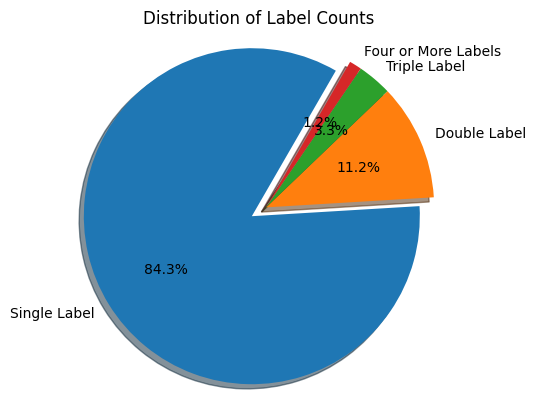

In [ ]:


# Count the number of labels per image
label_counts = df['Finding Labels'].str.split('|').apply(len)

# Calculate the distribution of label counts
total_images = len(df)
single_label_percent = (label_counts[label_counts == 1].count() / total_images) * 100
double_label_percent = (label_counts[label_counts == 2].count() / total_images) * 100
triple_label_percent = (label_counts[label_counts == 3].count() / total_images) * 100
four_or_more_label_percent = (label_counts[label_counts >= 4].count() / total_images) * 100

print(f"Single Label: {single_label_percent:.2f}%")
print(f"Double Label: {double_label_percent:.2f}%")
print(f"Triple Label: {triple_label_percent:.2f}%")
print(f"Four or More Labels: {four_or_more_label_percent:.2f}%")


# Count occurrences of each label
label_frequencies = {}
for labels in df['Finding Labels']:
    for label in labels.split('|'):
        label = label.strip()
        label_frequencies[label] = label_frequencies.get(label, 0) + 1

# Print label frequencies
for label, count in label_frequencies.items():
    print(f"{label}: {count} ({(count / total_images) * 100:.1f}%)")

# Create the pie chart
labels = ['Single Label', 'Double Label', 'Triple Label', 'Four or More Labels']
sizes = [single_label_percent, double_label_percent, triple_label_percent, four_or_more_label_percent]
explode = (0.1, 0, 0, 0)  # Explode the first slice (Single Label)

fig1, ax1 = plt.subplots()
ax1.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', shadow=True, startangle=60)
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.title('Distribution of Label Counts')
plt.show()


In [ ]:

# Analyze age distribution
print("Age statistics:")
print(df['Patient Age'].describe())

# Analyze gender distribution
gender_counts = df['Patient Gender'].value_counts()
print("\nGender distribution:")
print(gender_counts)

# Analyze view position distribution
view_position_counts = df['View Position'].value_counts()
print("\nView Position distribution:")
view_position_counts


Age statistics:
count    9999.000000
mean       49.194519
std        16.999237
min         4.000000
25%        39.000000
50%        51.000000
75%        61.000000
max        94.000000
Name: Patient Age, dtype: float64

Gender distribution:
Patient Gender
M    5106
F    4893
Name: count, dtype: int64

View Position distribution:


,count
View Position,
PA,6503
AP,3496


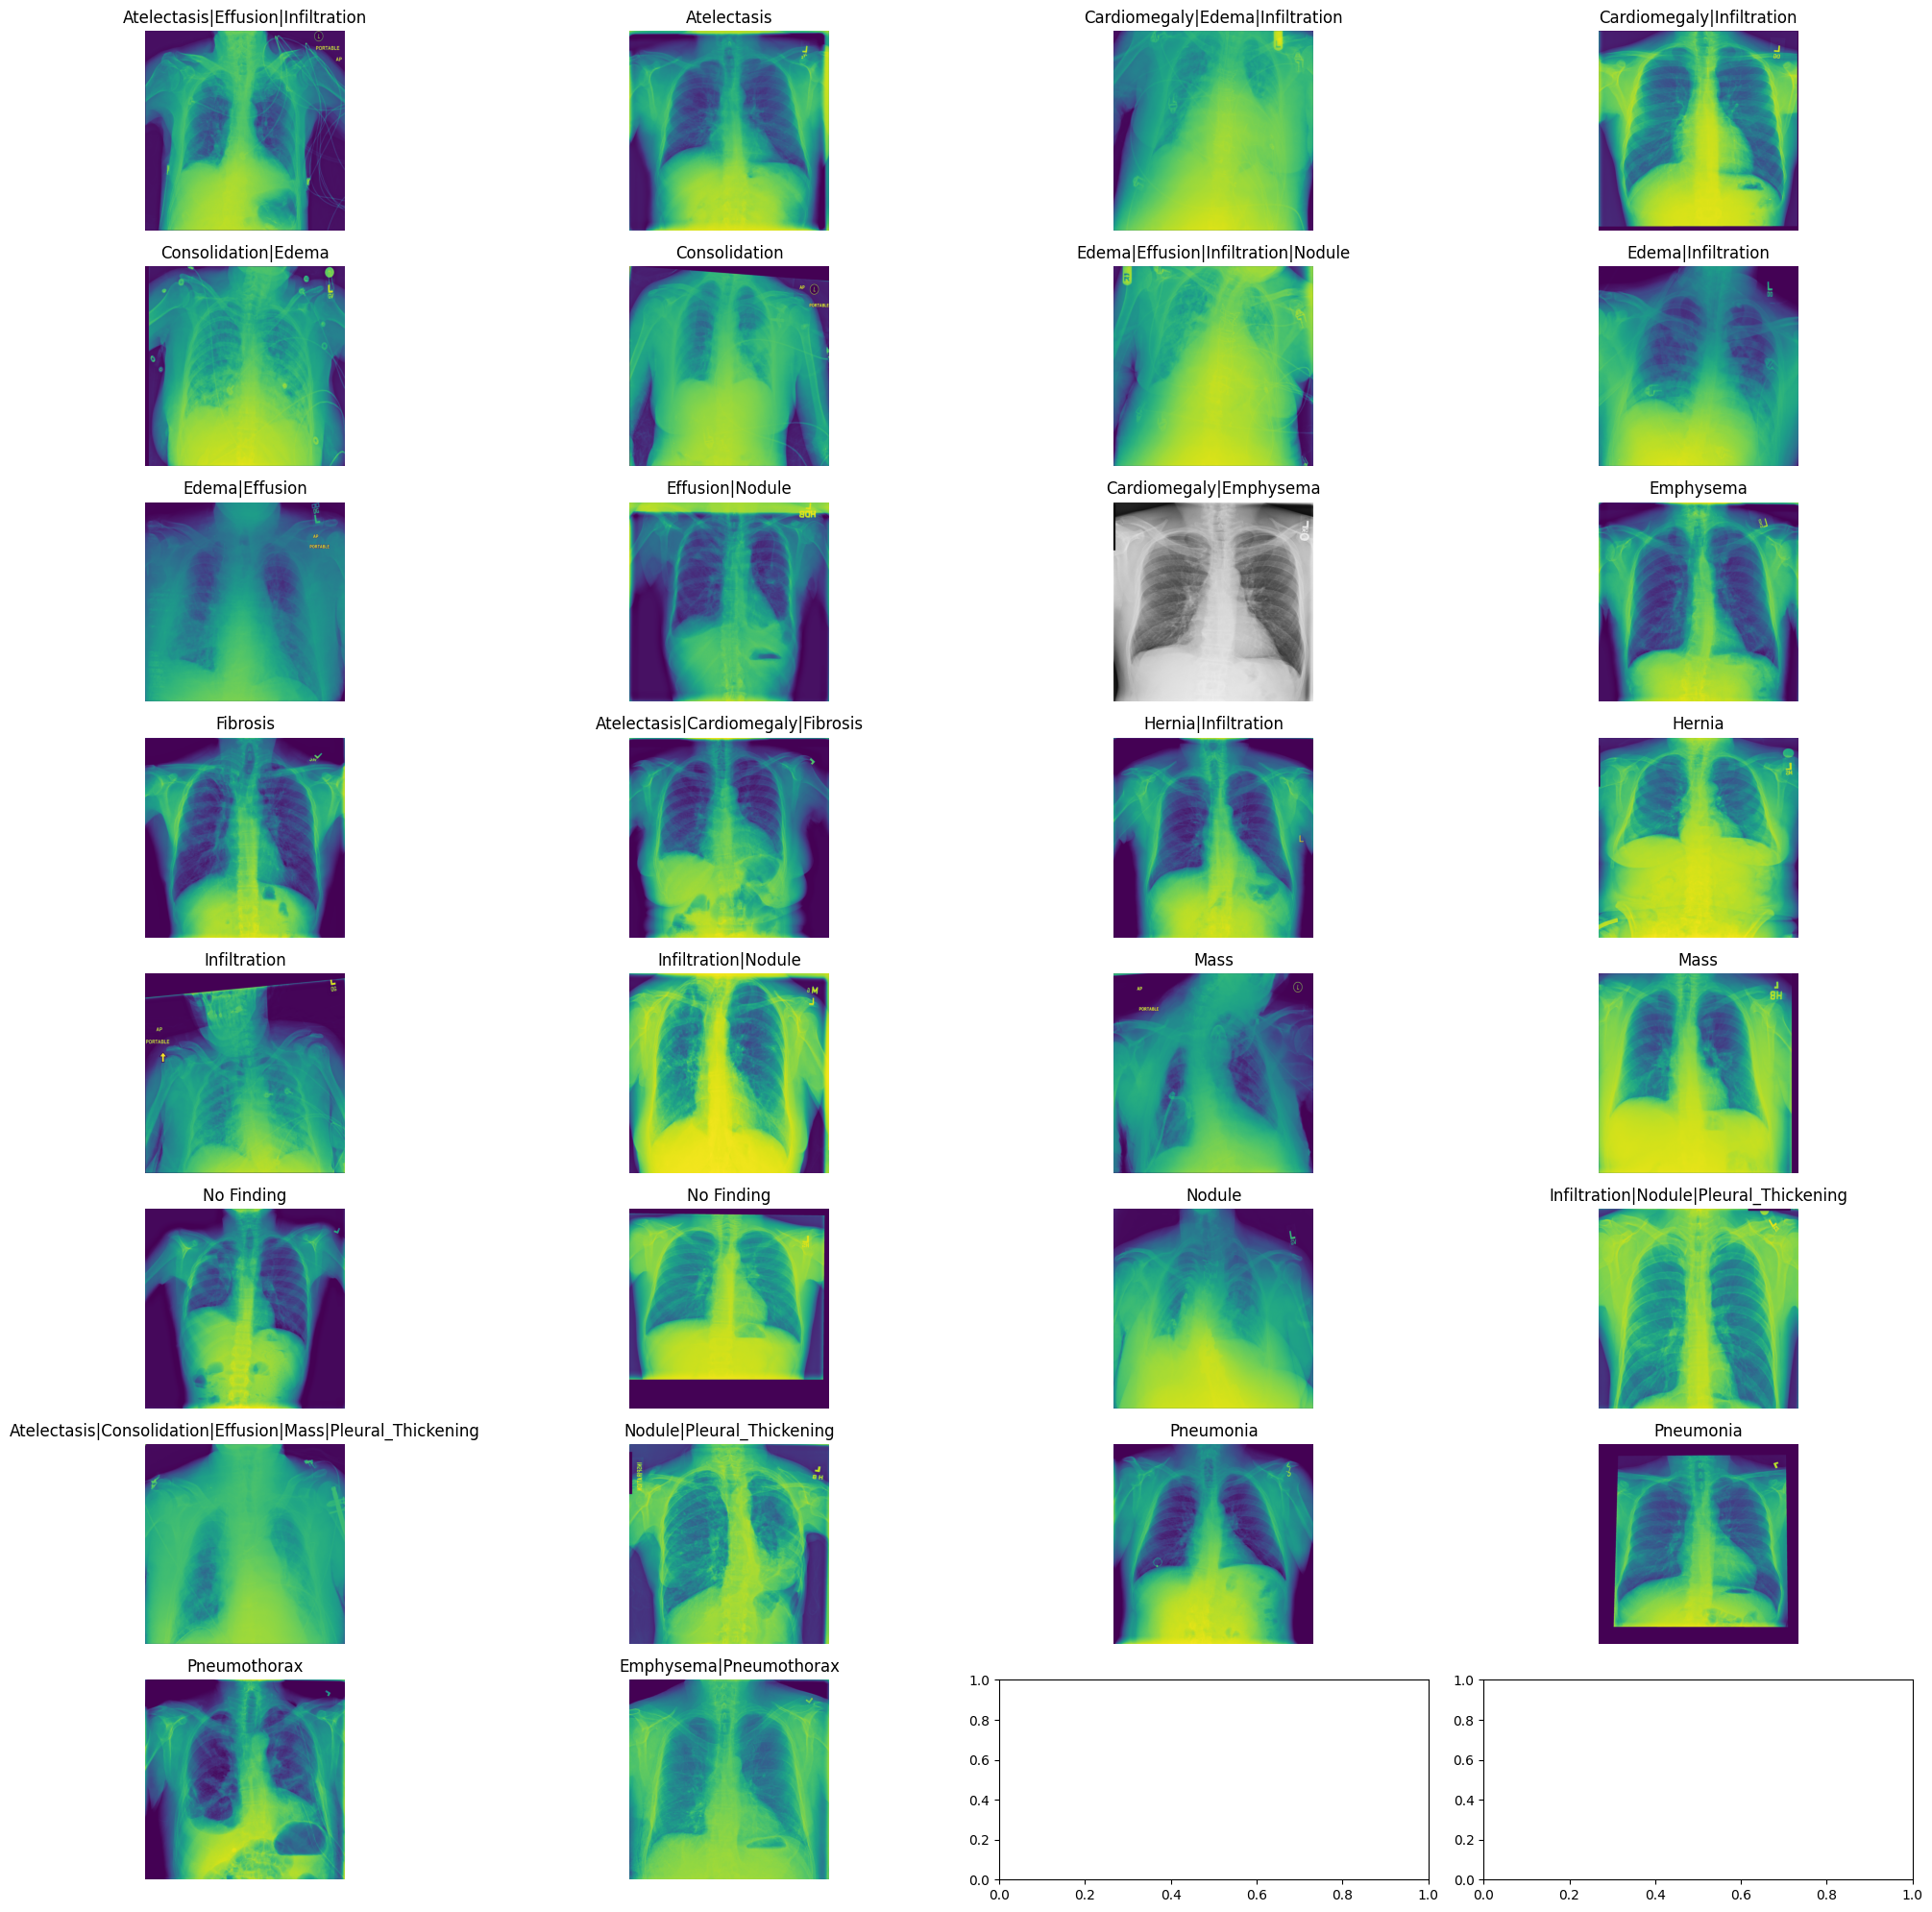

In [ ]:


# Select 16 random images, two per pathology category
selected_images = {}
for label in all_labels:
    images_with_label = df[df['Finding Labels'].str.contains(label)]
    if len(images_with_label) >= 2 :
        selected_images[label] = random.sample(list(images_with_label['Image Index']), 2)
    else:
        print(f"Not enough images for label {label}")

image_indices = []
for images in selected_images.values():
  image_indices.extend(images)

# Calculate the number of rows and columns needed for the subplots
num_images = len(image_indices)
num_cols = 4
num_rows = (num_images + num_cols - 1) // num_cols  # Calculate rows dynamically

# Display the selected images with their finding labels
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 20))  # Dynamic subplots
axes = axes.ravel()

for i, image_index in enumerate(image_indices):
    image_path = os.path.join(image_dir, image_index)
    try:
      img = plt.imread(image_path)
      axes[i].imshow(img)
      finding_labels = df.loc[df['Image Index'] == image_index, 'Finding Labels'].iloc[0]
      axes[i].set_title(finding_labels)
      axes[i].axis('off')
    except FileNotFoundError:
        print(f"Image not found: {image_path}")
    except IndexError:
        print(f"Skipping image {image_index} due to insufficient subplot space.")
        break

plt.tight_layout()
plt.show()

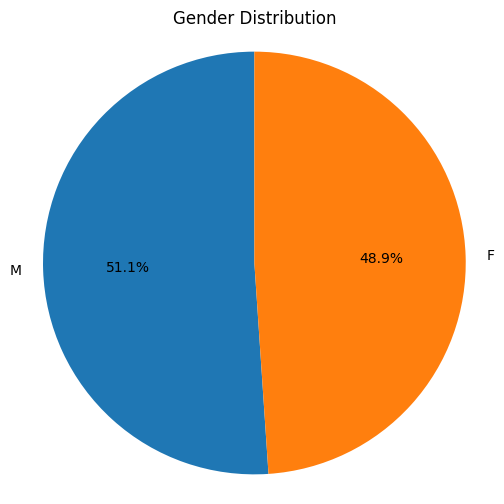

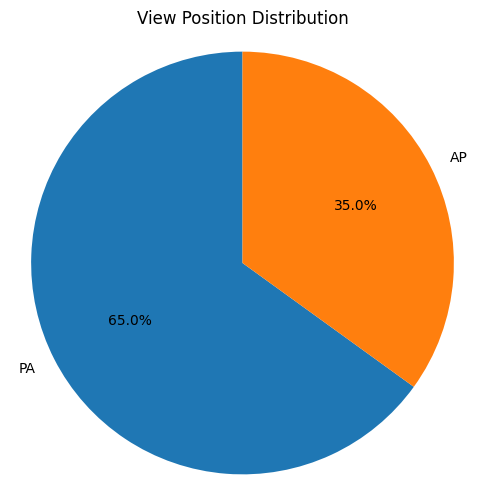

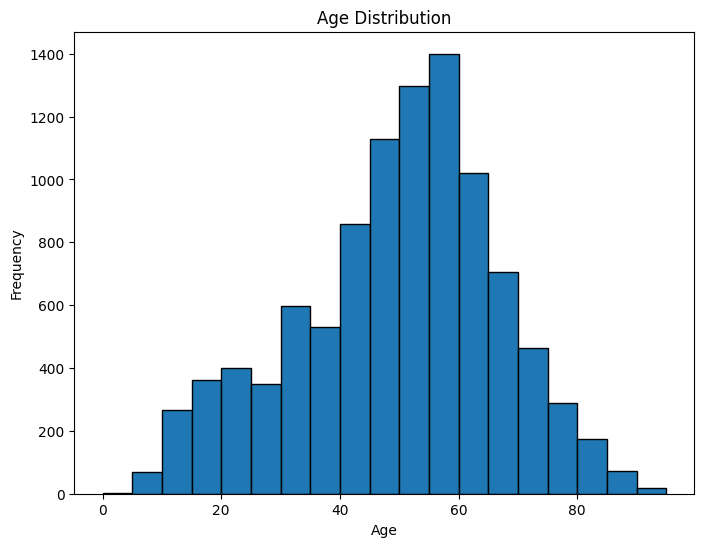

In [ ]:
# Analyze gender distribution
gender_counts = df['Patient Gender'].value_counts()
gender_percentages = (gender_counts / len(df)) * 100

# Create a pie chart for gender distribution
plt.figure(figsize=(6, 6))
plt.pie(gender_percentages, labels=gender_percentages.index, autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution')
plt.axis('equal')
plt.show()


# Analyze view position distribution
view_position_counts = df['View Position'].value_counts()
view_position_percentages = (view_position_counts / len(df)) * 100


# Create a pie chart for view position distribution
plt.figure(figsize=(6, 6))
plt.pie(view_position_percentages, labels=view_position_percentages.index, autopct='%1.1f%%', startangle=90)
plt.title('View Position Distribution')
plt.axis('equal')
plt.show()


# Analyze age distribution
plt.figure(figsize=(8, 6))
plt.hist(df['Patient Age'], bins=range(0, 100, 5), edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()


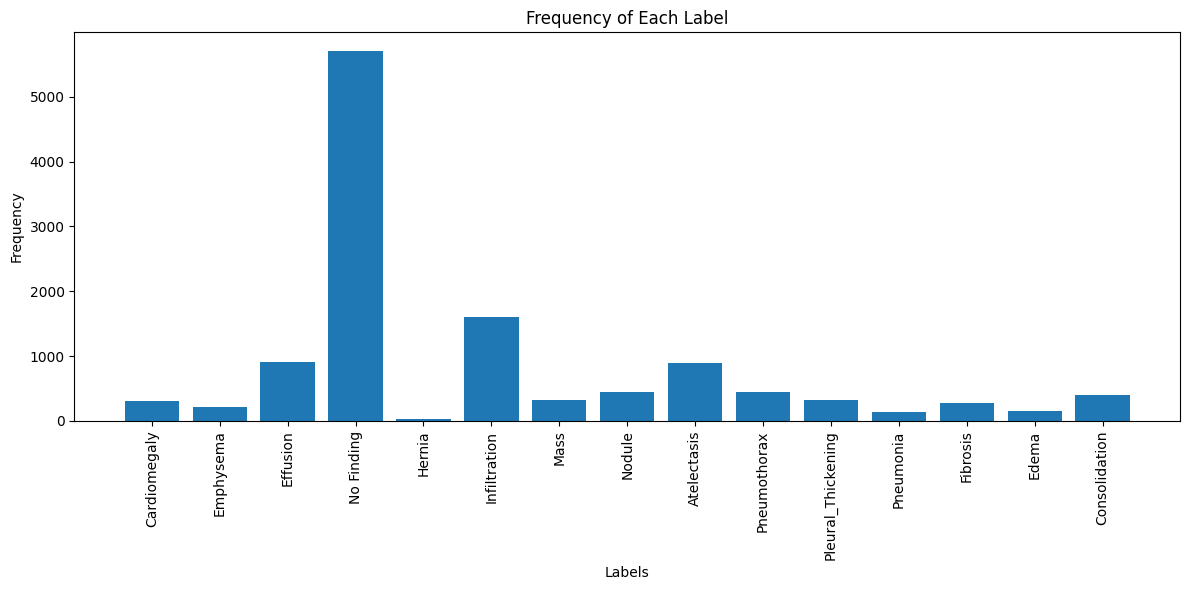

,Label,Frequency
0,Cardiomegaly,300
1,Emphysema,221
2,Effusion,907
3,No Finding,5708
4,Hernia,35
5,Infiltration,1603
6,Mass,328
7,Nodule,444
8,Atelectasis,889
9,Pneumothorax,440


In [ ]:
# Create a bar chart of label frequencies
labels = list(label_frequencies.keys())
frequencies = list(label_frequencies.values())

plt.figure(figsize=(12, 6))
plt.bar(labels, frequencies)
plt.xlabel("Labels")
plt.ylabel("Frequency")
plt.title("Frequency of Each Label")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Display label frequencies in a table
label_df = pd.DataFrame({'Label': labels, 'Frequency': frequencies})
label_df


In [ ]:

# Calculate the co-occurrence matrix
co_occurrence_matrix = np.zeros((num_labels, num_labels))
for _, row in df.iterrows():
    labels = row['Finding Labels'].split('|')
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            label1 = labels[i].strip()
            label2 = labels[j].strip()
            if label1 in label2idx and label2 in label2idx:
                co_occurrence_matrix[label2idx[label1], label2idx[label2]] += 1
                co_occurrence_matrix[label2idx[label2], label2idx[label1]] += 1

# Convert the co-occurrence matrix to a DataFrame for better visualization
co_occurrence_df = pd.DataFrame(co_occurrence_matrix, index=all_labels, columns=all_labels)

# Display the co-occurrence matrix
print("\nCo-occurrence Matrix:")
print(co_occurrence_df)

# Calculate the correlation matrix (using the co-occurrence matrix as input)
correlation_matrix = co_occurrence_df.corr()

# Display the correlation matrix
print("\nCorrelation Matrix:")
correlation_matrix



Co-occurrence Matrix:
                    Atelectasis  Cardiomegaly  Consolidation  Edema  Effusion  \
Atelectasis                 0.0          39.0           83.0   17.0     197.0   
Cardiomegaly               39.0           0.0           15.0   21.0     112.0   
Consolidation              83.0          15.0            0.0   13.0      87.0   
Edema                      17.0          21.0           13.0    0.0      55.0   
Effusion                  197.0         112.0           87.0   55.0       0.0   
Emphysema                  31.0          13.0            0.0    1.0      20.0   
Fibrosis                   18.0           9.0           18.0    2.0      23.0   
Hernia                      2.0           2.0            0.0    0.0       2.0   
Infiltration              228.0          56.0          105.0   60.0     249.0   
Mass                       39.0          13.0           37.0    4.0      53.0   
No Finding                  0.0           0.0            0.0    0.0       0.0   
Nodul

,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
Atelectasis,1.000000,0.787877,0.700006,0.908860,0.392698,0.421529,0.747757,0.652031,0.207671,0.819227,NaN,0.811709,0.816383,0.713774,0.684708
Cardiomegaly,0.787877,1.000000,0.785389,0.809039,0.213931,0.352826,0.513303,0.487542,0.644656,0.694156,NaN,0.549789,0.824085,0.751607,0.688076
Consolidation,0.700006,0.785389,1.000000,0.794999,0.636753,0.631073,0.758048,0.813161,0.532732,0.798577,NaN,0.714935,0.900778,0.865934,0.728410
Edema,0.908860,0.809039,0.794999,1.000000,0.501585,0.422961,0.748112,0.701985,0.332061,0.793277,NaN,0.749218,0.810452,0.766857,0.677319
Effusion,0.392698,0.213931,0.636753,0.501585,1.000000,0.541312,0.686306,0.704584,0.094793,0.643010,NaN,0.697907,0.423277,0.706770,0.580371
Emphysema,0.421529,0.352826,0.631073,0.422961,0.541312,1.000000,0.398533,0.471610,0.265617,0.566990,NaN,0.443032,0.528420,0.426128,0.340079
Fibrosis,0.747757,0.513303,0.758048,0.748112,0.686306,0.398533,1.000000,0.746244,0.215677,0.882872,NaN,0.802762,0.712972,0.781132,0.683411
Hernia,0.652031,0.487542,0.813161,0.701985,0.704584,0.471610,0.746244,1.000000,0.135259,0.606089,NaN,0.800424,0.707020,0.689949,0.666601
Infiltration,0.207671,0.644656,0.532732,0.332061,0.094793,0.265617,0.215677,0.135259,1.000000,0.414960,NaN,0.027242,0.531632,0.392517,0.352159
Mass,0.819227,0.694156,0.798577,0.793277,0.643010,0.566990,0.882872,0.606089,0.414960,1.000000,NaN,0.770658,0.808766,0.822207,0.753217


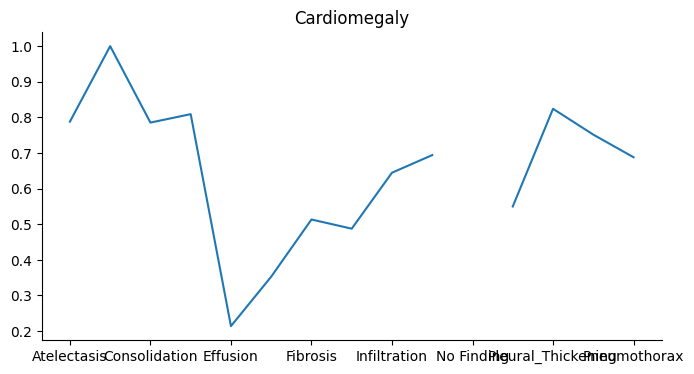

In [ ]:
# @title Cardiomegaly

from matplotlib import pyplot as plt
correlation_matrix['Cardiomegaly'].plot(kind='line', figsize=(8, 4), title='Cardiomegaly')
plt.gca().spines[['top', 'right']].set_visible(False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Image Index                  9999 non-null   object 
 1   Finding Labels               9999 non-null   object 
 2   Follow-up #                  9999 non-null   int64  
 3   Patient ID                   9999 non-null   int64  
 4   Patient Age                  9999 non-null   int64  
 5   Patient Gender               9999 non-null   object 
 6   View Position                9999 non-null   object 
 7   OriginalImage[Width          9999 non-null   int64  
 8   Height]                      9999 non-null   int64  
 9   OriginalImagePixelSpacing[x  9999 non-null   float64
 10  y]                           9999 non-null   float64
 11  encoded                      9999 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 937.5+ KB
None
        Imag

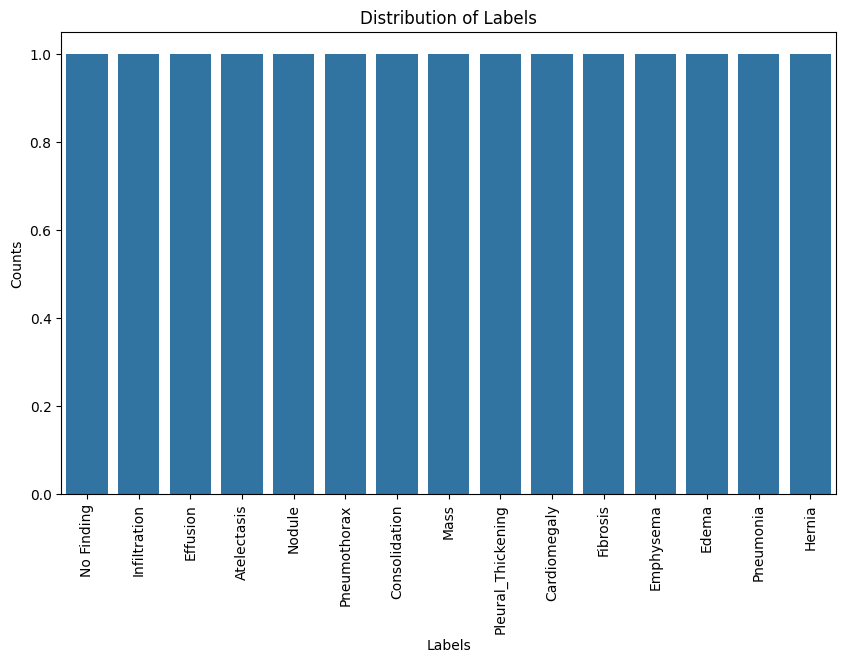

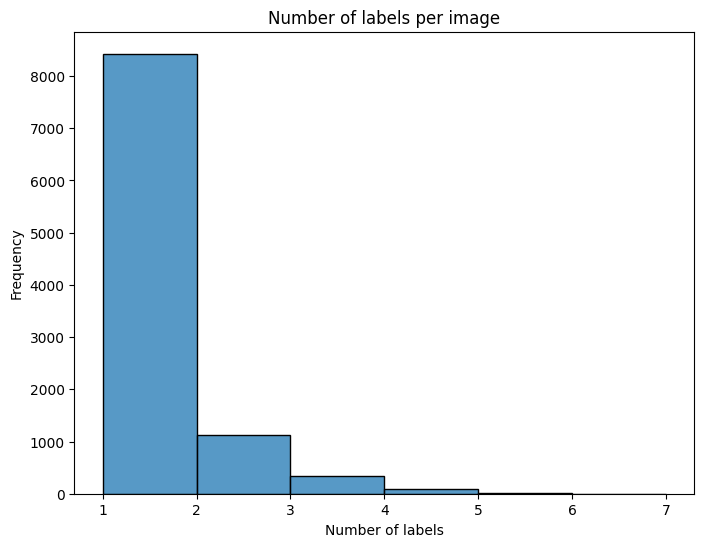

In [ ]:

# Display basic info about the DataFrame
print(df.info())

# Display the first few rows of the DataFrame
print(df.head())

# Summary statistics for numerical columns
print(df.describe())

# Check for missing values
print(df.isnull().sum())

# Analyze label distribution
label_counts = df['Finding Labels'].str.split('|').explode().value_counts()
print(label_counts)

plt.figure(figsize=(10, 6))
sns.countplot(x=label_counts.index, data=pd.DataFrame({'labels': label_counts.index, 'counts': label_counts.values}))
plt.xticks(rotation=90)
plt.title('Distribution of Labels')
plt.xlabel('Labels')
plt.ylabel('Counts')
plt.show()

# Analyze the distribution of the number of labels per image
label_counts_per_image = df['Finding Labels'].str.split('|').apply(len)
plt.figure(figsize=(8, 6))
sns.histplot(label_counts_per_image, bins=range(1, max(label_counts_per_image) + 2))
plt.title('Number of labels per image')
plt.xlabel('Number of labels')
plt.ylabel('Frequency')
plt.show()


In [ ]:
IMG_SIZE = 224  # DenseNet121 expects at least 224x224 images

def preprocess_image(filename, label, training=True):
    # Read image file
    img_path = tf.strings.join([image_dir, filename], separator=os.sep)
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    if training:
        # Advanced augmentation
        img = tf.image.resize(img, [int(IMG_SIZE*1.2), int(IMG_SIZE*1.2)])
        img = tf.image.random_crop(img, size=[IMG_SIZE, IMG_SIZE, 3])
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.1)
        img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    else:
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])

    # Normalize using ImageNet mean and std
    img = (img - [0.485, 0.456, 0.406]) / [0.229, 0.224, 0.225]
    return img, label

# Convert the DataFrame into a tf.data.Dataset
filenames = df['Image Index'].values
labels = np.stack(df['encoded'].values)

# Split into training and validation (for example, 80/20 split)
num_samples = len(filenames)
indices = np.arange(num_samples)
np.random.shuffle(indices)
split = int(0.8 * num_samples)

train_idx, val_idx = indices[:split], indices[split:]
train_filenames = filenames[train_idx]
train_labels = labels[train_idx]
val_filenames = filenames[val_idx]
val_labels = labels[val_idx]

# Create tf.data datasets
BATCH_SIZE = 16

train_ds = tf.data.Dataset.from_tensor_slices((train_filenames, train_labels))
train_ds = train_ds.map(lambda f, l: preprocess_image(f, l, training=True),
                        num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_filenames, val_labels))
val_ds = val_ds.map(lambda f, l: preprocess_image(f, l, training=False),
                    num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


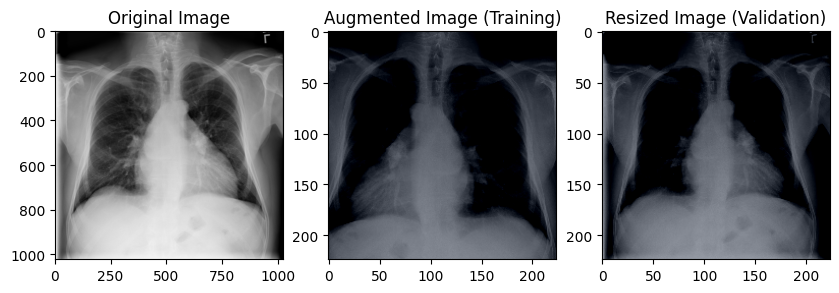

In [ ]:

example_filename = df['Image Index'].iloc[0]

# Preprocess the image for training
example_image_train, example_label_train = preprocess_image(example_filename, df['encoded'].iloc[0], training=True)

# Preprocess the image for validation/testing
example_image_val, example_label_val = preprocess_image(example_filename, df['encoded'].iloc[0], training=False)


# Display the original image
img_path = tf.strings.join([image_dir, example_filename], separator=os.sep)
original_image = tf.io.read_file(img_path)
original_image = tf.image.decode_png(original_image, channels=3)
original_image = tf.image.convert_image_dtype(original_image, tf.float32)


plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.title("Original Image")

plt.subplot(1, 3, 2)
plt.imshow(tf.clip_by_value((example_image_train + [0.485, 0.456, 0.406]) * [0.229, 0.224, 0.225], 0, 1))
plt.title("Augmented Image (Training)")

plt.subplot(1, 3, 3)
plt.imshow(tf.clip_by_value((example_image_val + [0.485, 0.456, 0.406]) * [0.229, 0.224, 0.225], 0, 1))
plt.title("Resized Image (Validation)")

plt.show()


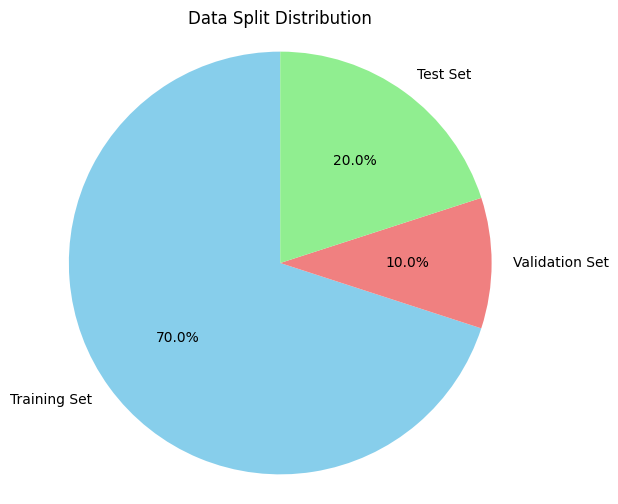

In [ ]:
total_patients = len(df)
train_size = int(0.7 * total_patients)
val_size = int(0.1 * total_patients)
test_size = total_patients - train_size - val_size

# Data for the pie chart
sizes = [train_size, val_size, test_size]
labels = ['Training Set', 'Validation Set', 'Test Set']
colors = ['skyblue', 'lightcoral', 'lightgreen']

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.title('Data Split Distribution')
plt.show()


In [ ]:
# Create the base model using DenseNet121 (excluding the top classification layers)
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
#base_model.trainable = False  # Freeze the base model for initial training

layer_name = "conv5_block16_concat"
feature_extractor = Model(inputs=base_model.input, outputs=base_model.get_layer(layer_name).output)


# Build the full model
x = feature_extractor.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
outputs = Dense(num_labels, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=outputs)


freeze = True
for layer in model.layers:
    if layer.name == layer_name:
        freeze = False
    if freeze:
        layer.trainable = False
    else:
        layer.trainable = True


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:

print("Trainable layers:")
for layer in model.layers:
    if layer.trainable:
        print(layer.name)


model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Trainable layers:
conv5_block16_concat
global_average_pooling2d
dropout
dense


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,048,783 (26.89 MB)

 Trainable params: 15,375 (60.06 KB)

 Non-trainable params: 7,033,408 (26.83 MB)

In [ ]:
#Set Up Callbacks such as a Learning Rate Scheduler and Model Checkpoint
lr_scheduler = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1)
checkpoint = callbacks.ModelCheckpoint('best_finetuned_model.h5', monitor='val_loss', save_best_only=True, verbose=1)

#Train the Model
EPOCHS = 10

history = model.fit(train_ds,
                    epochs=EPOCHS,
                    validation_data=val_ds,
                    callbacks=[lr_scheduler, checkpoint])

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4889 - loss: 0.5461
Epoch 1: val_loss improved from inf to 0.31426, saving model to best_finetuned_model.h5


500/500 ━━━━━━━━━━━━━━━━━━━━ 2385s 4s/step - accuracy: 0.4891 - loss: 0.5459 - val_accuracy: 0.5590 - val_loss: 0.3143 - learning_rate: 1.0000e-04
Epoch 2/10
499/500 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.5658 - loss: 0.2822
Epoch 2: val_loss improved from 0.31426 to 0.23974, saving model to best_finetuned_model.h5


500/500 ━━━━━━━━━━━━━━━━━━━━ 188s 339ms/step - accuracy: 0.5659 - loss: 0.2821 - val_accuracy: 0.5590 - val_loss: 0.2397 - learning_rate: 1.0000e-04
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.5727 - loss: 0.2272
Epoch 3: val_loss improved from 0.23974 to 0.21927, saving model to best_finetuned_model.h5


500/500 ━━━━━━━━━━━━━━━━━━━━ 199s 338ms/step - accuracy: 0.5727 - loss: 0.2272 - val_accuracy: 0.5590 - val_loss: 0.2193 - learning_rate: 1.0000e-04
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.5649 - loss: 0.2133
Epoch 4: val_loss improved from 0.21927 to 0.21210, saving model to best_finetuned_model.h5


500/500 ━━━━━━━━━━━━━━━━━━━━ 188s 340ms/step - accuracy: 0.5649 - loss: 0.2133 - val_accuracy: 0.5590 - val_loss: 0.2121 - learning_rate: 1.0000e-04
Epoch 5/10
499/500 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.5715 - loss: 0.2062
Epoch 5: val_loss improved from 0.21210 to 0.20906, saving model to best_finetuned_model.h5


...

500/500 ━━━━━━━━━━━━━━━━━━━━ 186s 338ms/step - accuracy: 0.5696 - loss: 0.2038 - val_accuracy: 0.5590 - val_loss: 0.2076 - learning_rate: 1.0000e-04
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.5683 - loss: 0.2034
Epoch 7: val_loss improved from 0.20760 to 0.20674, saving model to best_finetuned_model.h5


500/500 ━━━━━━━━━━━━━━━━━━━━ 202s 340ms/step - accuracy: 0.5683 - loss: 0.2034 - val_accuracy: 0.5590 - val_loss: 0.2067 - learning_rate: 1.0000e-04
Epoch 8/10
499/500 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.5671 - loss: 0.2028
Epoch 8: val_loss improved from 0.20674 to 0.20616, saving model to best_finetuned_model.h5


500/500 ━━━━━━━━━━━━━━━━━━━━ 195s 327ms/step - accuracy: 0.5671 - loss: 0.2028 - val_accuracy: 0.5590 - val_loss: 0.2062 - learning_rate: 1.0000e-04
Epoch 9/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.5666 - loss: 0.2020
Epoch 9: val_loss improved from 0.20616 to 0.20571, saving model to best_finetuned_model.h5


500/500 ━━━━━━━━━━━━━━━━━━━━ 203s 327ms/step - accuracy: 0.5666 - loss: 0.2020 - val_accuracy: 0.5590 - val_loss: 0.2057 - learning_rate: 1.0000e-04
Epoch 10/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.5682 - loss: 0.2003
Epoch 10: val_loss improved from 0.20571 to 0.20532, saving model to best_finetuned_model.h5


500/500 ━━━━━━━━━━━━━━━━━━━━ 191s 349ms/step - accuracy: 0.5683 - loss: 0.2003 - val_accuracy: 0.5590 - val_loss: 0.2053 - learning_rate: 1.0000e-04


In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)
    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=all_labels, zero_division=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

In [ ]:

def get_image_paths(image_dir):
    image_paths = []
    for root, _, files in os.walk(image_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(root, file))
    return image_paths


image_dir = '/content/drive/Othercomputers/My Laptop/projectDrive/images'
all_image_paths = get_image_paths(image_dir)

if all_image_paths:
    example_img_path = all_image_paths[4]  # Select the first image
    print(f"Selected image path: {example_img_path}")

else:
    print("No images found in the specified directory.")


Selected image path: /content/drive/Othercomputers/My Laptop/projectDrive/images/00023065_002.png


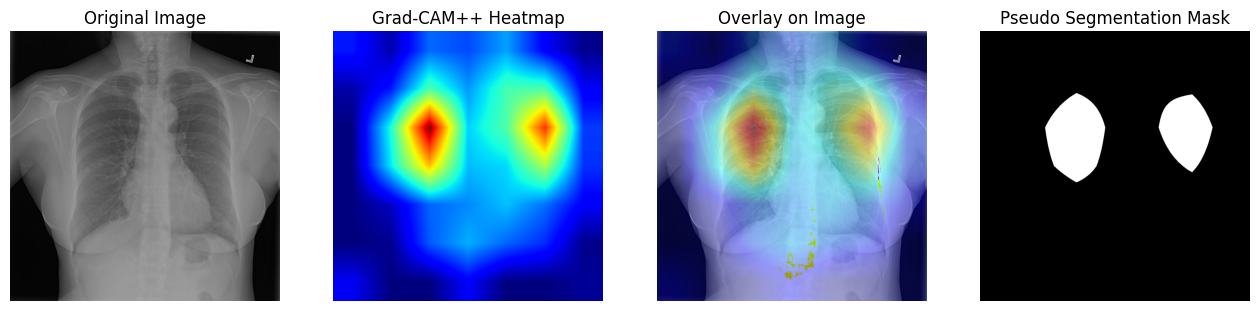

In [ ]:

IMG_SIZE = 224

# Function to load and preprocess a single image
def load_preprocess_image(img_path, target_size=(IMG_SIZE, IMG_SIZE)):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, target_size)
    # Normalize with ImageNet statistics
    img = (img - [0.485, 0.456, 0.406]) / [0.229, 0.224, 0.225]
    # Expand dims to create a batch of 1
    return tf.expand_dims(img, axis=0)

# Function to compute Grad-CAM heatmap for a given image and model
def get_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Directly get the target convolutional layer by name from the model
    try:
        conv_layer = model.get_layer(last_conv_layer_name)
    except ValueError:
        raise ValueError(f"Layer '{last_conv_layer_name}' not found in model. Please verify the layer name.")

    # Create a model that maps the input image to the activations
    # of the last conv layer and the model output
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[conv_layer.output, model.output]
    )

    # Record operations for automatic differentiation
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:

            # Here we select the class with the highest predicted score.
            pred_index = tf.argmax(predictions[0])
        target_class_channel = predictions[:, pred_index]

    # Compute gradients of the target class with respect to the output feature map
    grads = tape.gradient(target_class_channel, conv_outputs)

    # Compute the channel-wise mean of the gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))


    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Apply ReLU to the heatmap and normalize between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

# Function to display the original image, Grad-CAM heatmap, overlay, and pseudo segmentation mask
def display_gradcam(img_path, heatmap, alpha=0.4, threshold=0.5):
    # Load the original image using cv2 for display
    orig_img = cv2.imread(img_path)
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

    # Resize heatmap to match original image dimensions
    heatmap_resized = cv2.resize(heatmap, (orig_img.shape[1], orig_img.shape[0]))

    # Create a color map from the heatmap
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Superimpose the heatmap onto the original image
    superimposed_img = heatmap_colored * alpha + orig_img
    superimposed_img = np.uint8(superimposed_img)

    # Generate a pseudo segmentation mask by thresholding the heatmap
    pseudo_mask = (heatmap_resized > threshold).astype(np.uint8) * 255

    # Plot all visualizations
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.title("Original Image")
    plt.imshow(orig_img)
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.title("Grad-CAM++ Heatmap")
    plt.imshow(heatmap_resized, cmap='jet')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.title("Overlay on Image")
    plt.imshow(superimposed_img)
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.title("Pseudo Segmentation Mask")
    plt.imshow(pseudo_mask, cmap='gray')
    plt.axis('off')

    plt.show()

example_img_path = '/content/drive/Othercomputers/My Laptop/projectDrive/images/00023065_002.png'

# Load and preprocess the image
img_array = load_preprocess_image(example_img_path, target_size=(IMG_SIZE, IMG_SIZE))

# Specify the name of the last convolutional layer in DenseNet121.
last_conv_layer_name = "conv5_block16_concat"

# Compute the Grad-CAM heatmap
heatmap = get_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None)

# Display the Grad-CAM visualizations and the pseudo segmentation mask
display_gradcam(example_img_path, heatmap, alpha=0.4, threshold=0.5)


In [ ]:
# Create a DataFrame with the true labels
df_labels = pd.DataFrame(y_true, columns=all_labels)

# Compute the correlation matrix
corr_matrix = df_labels.corr()

print("Correlation Matrix:")
print(corr_matrix)

# Plotting the correlation matrix using seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of True Labels")
plt.show()


NameError: name 'y_true' is not defined

In [ ]:

from sklearn.metrics import jaccard_score, f1_score

def calculate_metrics(y_true, y_pred, labels):

    metrics = {}
    for i, label in enumerate(labels):
        metrics[label] = {}

        # Calculate IoU (Jaccard index)
        iou = jaccard_score(y_true[:, i], y_pred[:, i])
        metrics[label]['IoU'] = iou

        # Calculate Dice coefficient (F1-score)
        dice = f1_score(y_true[:, i], y_pred[:, i])
        metrics[label]['Dice'] = dice

        # Calculate Precision and Recall

        # Precision (positive predictive value)
        tp = np.sum((y_true[:,i] == 1) & (y_pred[:,i] == 1))
        fp = np.sum((y_true[:,i] == 0) & (y_pred[:,i] == 1))

        if (tp + fp) == 0:
            precision = 0
        else:
            precision = tp / (tp + fp)


        metrics[label]['Precision'] = precision

        # Recall (sensitivity or true positive rate)
        fn = np.sum((y_true[:,i] == 1) & (y_pred[:,i] == 0))

        if (tp + fn) == 0:
            recall = 0
        else:
            recall = tp / (tp + fn)

        metrics[label]['Recall'] = recall

    return metrics


pathology_metrics = calculate_metrics(y_true, y_pred, all_labels)

# Display the calculated metrics
for pathology, metric_values in pathology_metrics.items():
    print(f"Metrics for {pathology}:")
    for metric, value in metric_values.items():
        print(f"  {metric}: {value}")

# Calculate mean IoU and mean Dice
mean_iou = np.mean([metric_values['IoU'] for metric_values in pathology_metrics.values()])
mean_dice = np.mean([metric_values['Dice'] for metric_values in pathology_metrics.values()])
mean_precision = np.mean([metric_values['Precision'] for metric_values in pathology_metrics.values()])
mean_recall = np.mean([metric_values['Recall'] for metric_values in pathology_metrics.values()])


print(f"\nMean IoU: {mean_iou}")
print(f"Mean Dice: {mean_dice}")
print(f"Mean Precision: {mean_precision}")
print(f"Mean Recall: {mean_recall}")


Metrics for Atelectasis:
  IoU: 0.0
  Dice: 0.0
  Precision: 0
  Recall: 0.0
Metrics for Cardiomegaly:
  IoU: 0.0
  Dice: 0.0
  Precision: 0
  Recall: 0.0
Metrics for Consolidation:
  IoU: 0.0
  Dice: 0.0
  Precision: 0
  Recall: 0.0
Metrics for Edema:
  IoU: 0.0
  Dice: 0.0
  Precision: 0
  Recall: 0.0
Metrics for Effusion:
  IoU: 0.0
  Dice: 0.0
  Precision: 0
  Recall: 0.0
Metrics for Emphysema:
  IoU: 0.0
  Dice: 0.0
  Precision: 0
  Recall: 0.0
Metrics for Fibrosis:
  IoU: 0.0
  Dice: 0.0
  Precision: 0
  Recall: 0.0
Metrics for Hernia:
  IoU: 0.0
  Dice: 0.0
  Precision: 0
  Recall: 0.0
Metrics for Infiltration:
  IoU: 0.0
  Dice: 0.0
  Precision: 0
  Recall: 0.0
Metrics for Mass:
  IoU: 0.0
  Dice: 0.0
  Precision: 0
  Recall: 0.0
Metrics for No Finding:
  IoU: 0.5645336225596529
  Dice: 0.7216637781629116
  Precision: 0.5891341256366723
  Recall: 0.9311270125223614
Metrics for Nodule:
  IoU: 0.0
  Dice: 0.0
  Precision: 0
  Recall: 0.0
Metrics for Pleural_Thickening:
  IoU: 0.0

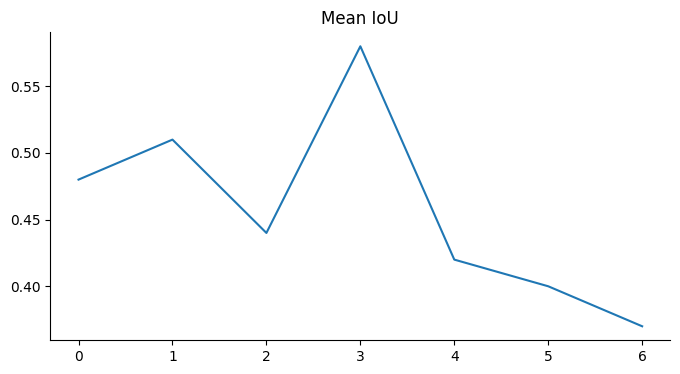

In [ ]:
# @title Mean IoU

from matplotlib import pyplot as plt
df_table6_2['Mean IoU'].plot(kind='line', figsize=(8, 4), title='Mean IoU')
plt.gca().spines[['top', 'right']].set_visible(False)

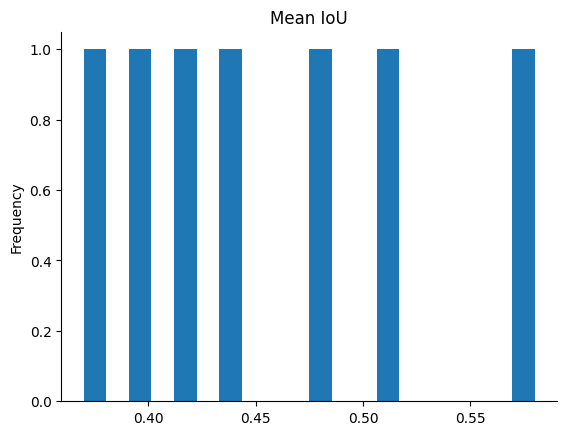

In [ ]:
# @title Mean IoU

from matplotlib import pyplot as plt
df_table6_2['Mean IoU'].plot(kind='hist', bins=20, title='Mean IoU')
plt.gca().spines[['top', 'right',]].set_visible(False)